# Aktivitas Hands-on: Preprocessing Dataset Titanic

Nama: Novi Shandi  
NIM: 240401010291  

Mata Kuliah: Pengantar Data Science  
Pertemuan 6 — Persiapan Data

In [20]:
# =========================================================
# 1. IMPORT LIBRARY
# =========================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Import Library

Library yang digunakan:
- pandas → mengolah data
- numpy → operasi numerik
- seaborn → mengambil dataset Titanic
- matplotlib → visualisasi data
- train_test_split → membagi data train dan test
- StandardScaler → normalisasi data numerik

In [21]:
# =========================================================
# 2. LOAD DATASET TITANIC
# =========================================================

df = sns.load_dataset('titanic')

# Memilih kolom yang digunakan
cols = [
    'pclass',
    'sex',
    'age',
    'sibsp',
    'parch',
    'fare',
    'embarked',
    'survived'
]

df = df[cols].copy()

# Menampilkan 5 data awal
print(df.head())

   pclass     sex   age  sibsp  parch     fare embarked  survived
0       3    male  22.0      1      0   7.2500        S         0
1       1  female  38.0      1      0  71.2833        C         1
2       3  female  26.0      0      0   7.9250        S         1
3       1  female  35.0      1      0  53.1000        S         1
4       3    male  35.0      0      0   8.0500        S         0


## Load Dataset

Dataset Titanic digunakan karena memiliki:
- data numerik,
- data kategorikal,
- missing values,
- dan target klasifikasi.

Kolom target pada dataset ini adalah `survived`:
- 1 = selamat
- 0 = tidak selamat

In [22]:
# =========================================================
# 3. EDA SINGKAT
# =========================================================

print("Shape Dataset:")
print(df.shape)

print("\nTipe Data:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDistribusi Target:")
print(df['survived'].value_counts(normalize=True).round(3))

Shape Dataset:
(891, 8)

Tipe Data:
pclass        int64
sex          object
age         float64
sibsp         int64
parch         int64
fare        float64
embarked     object
survived      int64
dtype: object

Missing Values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi Target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


## Analisis EDA

Berdasarkan hasil eksplorasi data:
- Dataset memiliki missing values pada kolom `age` dan `embarked`.
- Kolom `survived` digunakan sebagai target klasifikasi.
- Distribusi target menunjukkan jumlah penumpang yang tidak selamat lebih banyak dibandingkan yang selamat.

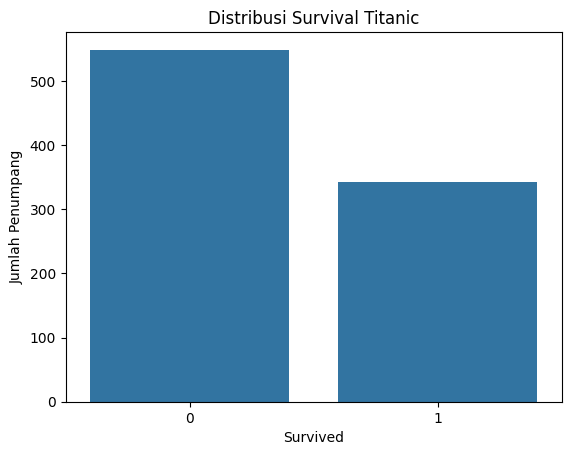

In [23]:
# =========================================================
# 4. VISUALISASI TARGET
# =========================================================

sns.countplot(
    data=df,
    x='survived'
)

plt.title('Distribusi Survival Titanic')
plt.xlabel('Survived')
plt.ylabel('Jumlah Penumpang')

plt.show()

## Analisis Distribusi Target

Grafik menunjukkan bahwa jumlah penumpang yang tidak selamat lebih banyak dibandingkan yang selamat. Hal ini menunjukkan dataset memiliki ketidakseimbangan kelas (imbalanced dataset).

In [24]:
# =========================================================
# 5. HANDLING MISSING VALUES
# =========================================================

# Mengisi missing value age dengan median
df['age'] = df['age'].fillna(
    df['age'].median()
)

# Mengisi missing value embarked dengan modus
df['embarked'] = df['embarked'].fillna(
    df['embarked'].mode()[0]
)

print("Missing Values Setelah Handling:")
print(df.isnull().sum())

Missing Values Setelah Handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


## Handling Missing Values

Missing value pada:
- `age` diisi menggunakan median karena lebih robust terhadap outlier.
- `embarked` diisi menggunakan modus karena merupakan data kategorikal.

Setelah preprocessing, seluruh missing values berhasil diatasi.

In [25]:
# =========================================================
# 6. ONE HOT ENCODING
# =========================================================

df = pd.get_dummies(
    df,
    columns=['sex', 'embarked'],
    drop_first=True,
    dtype=int
)

print("Kolom Setelah Encoding:")
print(df.columns.tolist())

print("\nData Setelah Encoding:")
print(df.head())

Kolom Setelah Encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']

Data Setelah Encoding:
   pclass   age  sibsp  parch     fare  survived  sex_male  embarked_Q  \
0       3  22.0      1      0   7.2500         0         1           0   
1       1  38.0      1      0  71.2833         1         0           0   
2       3  26.0      0      0   7.9250         1         0           0   
3       1  35.0      1      0  53.1000         1         0           0   
4       3  35.0      0      0   8.0500         0         1           0   

   embarked_S  
0           1  
1           0  
2           1  
3           1  
4           1  


## One Hot Encoding

Kolom kategorikal:
- `sex`
- `embarked`

diubah menjadi data numerik menggunakan One-Hot Encoding agar dapat diproses oleh algoritma machine learning.

In [26]:
# =========================================================
# 7. TRAIN TEST SPLIT
# =========================================================

X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Jumlah Data Train : {X_train.shape[0]}")
print(f"Jumlah Data Test  : {X_test.shape[0]}")

print("\nProporsi Target Train:")
print(y_train.value_counts(normalize=True).round(3))

print("\nProporsi Target Test:")
print(y_test.value_counts(normalize=True).round(3))

Jumlah Data Train : 712
Jumlah Data Test  : 179

Proporsi Target Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi Target Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## Train-Test Split

Dataset dibagi menjadi:
- 80% data training
- 20% data testing

Parameter `stratify=y` digunakan agar proporsi kelas target tetap seimbang pada train dan test set.

In [27]:
# =========================================================
# 8. FEATURE SCALING
# =========================================================

# Kolom numerik
num_cols = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

# Membuat scaler
scaler = StandardScaler()

# Fit dan transform data train
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

# Transform data test
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

print("Mean Scaler:")
print(scaler.mean_.round(2))

print("\nStd Scaler:")
print(scaler.scale_.round(2))

print("\nContoh X_train Setelah Scaling:")
print(X_train.head().round(3))

Mean Scaler:
[ 2.31 29.46  0.49  0.39 31.82]

Std Scaler:
[ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train Setelah Scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1
855   0.830 -0.880 -0.465  0.728 -0.468         0           0           1
801  -0.371  0.118  0.478  0.728 -0.116         0           0           1


## Feature Scaling

Feature Scaling dilakukan menggunakan StandardScaler untuk:
- menyamakan skala data,
- mempercepat proses machine learning,
- dan meningkatkan performa model.

Scaling hanya dilakukan pada kolom numerik:
- pclass
- age
- sibsp
- parch
- fare

In [28]:
# =========================================================
# 9. DATA AKHIR
# =========================================================

print("Shape X_train :", X_train.shape)
print("Shape y_train :", y_train.shape)

print("Shape X_test  :", X_test.shape)
print("Shape y_test  :", y_test.shape)

print("\nData siap digunakan untuk Machine Learning!")

Shape X_train : (712, 8)
Shape y_train : (712,)
Shape X_test  : (179, 8)
Shape y_test  : (179,)

Data siap digunakan untuk Machine Learning!


# Kesimpulan

Pada praktikum ini dilakukan preprocessing dataset Titanic menggunakan beberapa tahapan penting, yaitu:
- handling missing values,
- encoding data kategorikal,
- train-test split,
- dan feature scaling.

Hasil preprocessing menghasilkan dataset yang bersih dan siap digunakan untuk proses machine learning.